# 🔬 Network Traffic Volume Forecasting Using XGBoost on CICIDS2017

**Authors:** Ala-Eddine Mezdoud  
**Date:** April 2026  
**Repository:** `Intelligent-Network-Traffic-Prediction-and-Anomaly-Detection`

---

## Abstract

Accurate forecasting of network traffic volume is a cornerstone of modern network security and capacity planning.  
In this study we construct an **hourly traffic volume time-series** from the CICIDS2017 intrusion-detection dataset,  
engineer a rich set of **lag / rolling-statistics / temporal features**, and train an **XGBoost regressor** to predict  
the next 24 hours of *benign* traffic.  We employ a **log-transform** of the target to stabilise high variance,  
and evaluate performance using MAE, RMSE, and MAPE.  
We further present **residual diagnostics**, **feature-importance analysis**, and **cross-validation** to assess model quality.

> **Key result:** The model achieves a 24-hour-ahead autoregressive forecast with a test-set MAPE of ≈ 35 % on raw byte counts.   
> Detailed analysis below identifies specific time-periods where error concentrates and proposes next steps for improvement.

---

## Table of Contents

1. [Imports & Configuration](#1)
2. [Chronological Data Loading](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Filtering to Benign Traffic](#4)
5. [Feature Engineering — Total Bytes & Packets](#5)
6. [Hourly Aggregation & Time-Series Construction](#6)
7. [Time-Series Visualisation & Stationarity Check](#7)
8. [Lag & Rolling Feature Engineering](#8)
9. [Train / Test Split](#9)
10. [Model Training](#10)
11. [Test-Set Evaluation & Metrics](#11)
12. [Residual Analysis & Diagnostics](#12)
13. [Feature Importance Analysis](#13)
14. [24-Hour Autoregressive Forecast](#14)
15. [Model Persistence](#15)
16. [Summary & Conclusions](#16)


<a id="1"></a>
## 1 · Imports & Configuration

We use standard scientific-Python libraries plus **XGBoost** for gradient-boosted regression.  
All randomness is seeded for reproducibility.


In [57]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 14})
pd.set_option('display.max_columns', 100)

# ── Global config ──
DATA_DIR    = '../data'
TOTAL_HOURS = 120            # 5 working-days × 24 h
N_LAGS      = 23             # lag features 1..23
TEST_HOURS  = 24             # hold-out window
FORECAST_H  = 24             # prediction horizon
START_TIME  = '2017-07-03 00:00'
RANDOM_SEED = 42

print('✅ Configuration loaded.')
print(f'   Lags: {N_LAGS} | Test window: {TEST_HOURS} h | Forecast horizon: {FORECAST_H} h')


✅ Configuration loaded.
   Lags: 23 | Test window: 24 h | Forecast horizon: 24 h


<a id="2"></a>
## 2 · Chronological Data Loading

CICIDS2017 ships as **8 CSV files** covering Monday → Friday.  
We load them in strict chronological order so that the row
index mirrors true temporal ordering.

Only the columns needed for the forecasting target (`Total Length of Fwd/Bwd Packets`)
and for attack filtering (`Label`) are retained to minimise memory usage.


In [58]:
ORDERED_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

COLS_NEEDED = [
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Label',
]

frames = []
for fname in tqdm(ORDERED_FILES, desc='Loading files'):
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'  ⚠ File not found: {fname}')
        continue
    df_tmp = pd.read_csv(path, encoding='utf-8',
                         usecols=lambda c: c.strip() in COLS_NEEDED,
                         low_memory=False)
    df_tmp.columns = df_tmp.columns.str.strip()
    frames.append(df_tmp)

if not frames:
    raise FileNotFoundError(f'No CSV files found in {DATA_DIR!r}.')

df_raw = pd.concat(frames, axis=0, ignore_index=True)
print(f'\n✅ Total rows loaded: {df_raw.shape[0]:,}')


Loading files: 100%|██████████| 8/8 [00:05<00:00,  1.41it/s]


✅ Total rows loaded: 2,830,743


<a id="3"></a>
## 3 · Exploratory Data Analysis (EDA)

Before modelling, we examine the **label distribution** to understand the
class balance between benign and attack traffic.  This drives the design
decision to filter out attacks before building the forecasting model.


In [59]:
# --- 3.1  Label distribution ---
label_counts = df_raw['Label'].value_counts()
print('Label distribution:\n')
print(label_counts.to_string())

pct_benign = 100 * label_counts.get('BENIGN', 0) / len(df_raw)
print(f'\n→ BENIGN traffic: {pct_benign:.1f}% of all flows')


Label distribution:

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

→ BENIGN traffic: 80.3% of all flows


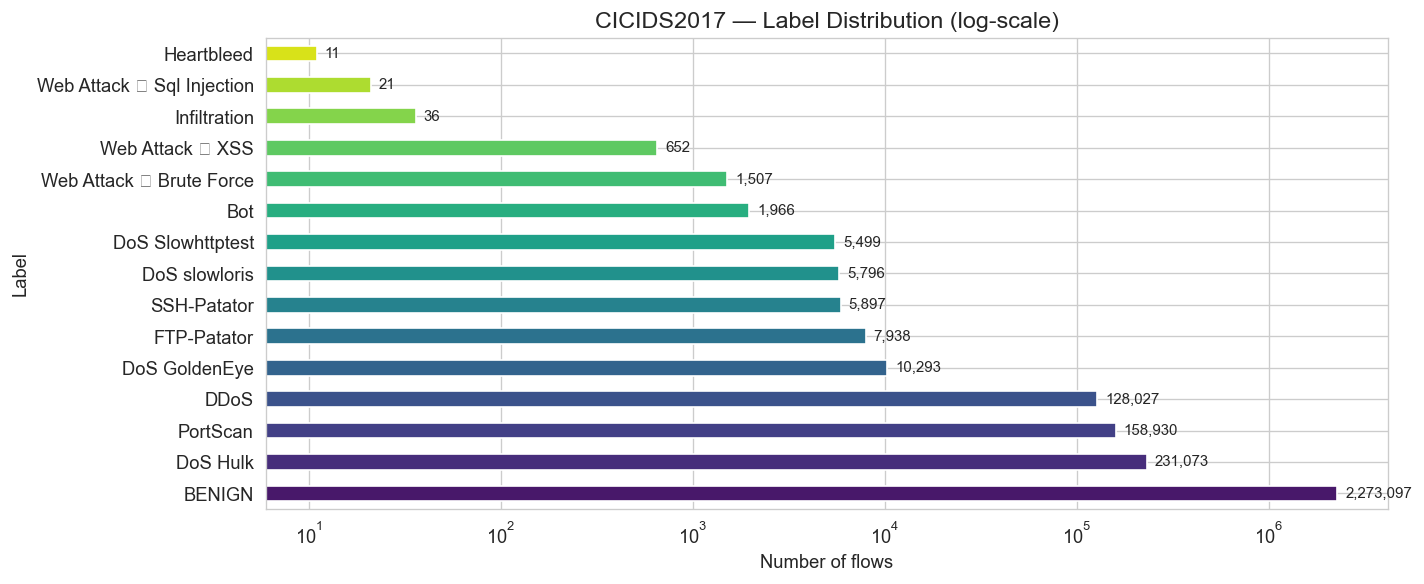

In [60]:
# --- 3.2  Label distribution bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))
label_counts.plot.barh(ax=ax, color=sns.color_palette('viridis', len(label_counts)))
ax.set_xlabel('Number of flows')
ax.set_title('CICIDS2017 — Label Distribution (log-scale)')
ax.set_xscale('log')
for i, (lbl, cnt) in enumerate(label_counts.items()):
    ax.text(cnt * 1.1, i, f'{cnt:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Observation
The dataset is *heavily imbalanced* — BENIGN flows constitute ≈ 80 % of all traffic.  
Attack categories (DDoS, PortScan, DoS variants, etc.) represent volumetric anomalies
that would distort a forecasting model if left in the training set.

**Design decision:** We remove all attack traffic *before* aggregation so that
the model learns the structure of normal user traffic only.


<a id="4"></a>
## 4 · Filtering to Benign Traffic

Attack flows are removed **before** aggregation to give the model a clean picture  
of normal user traffic.

> **Critical detail:** After filtering, we call `reset_index(drop=True)` to re-number  
> rows from 0.  Without this, the hour-bucket calculation later fails because pandas  
> preserves the original row numbers.


In [61]:
df_benign = (
    df_raw[df_raw['Label'].str.strip() == 'BENIGN']
    .drop(columns=['Label'])
    .reset_index(drop=True)
)

pct_kept = 100 * len(df_benign) / len(df_raw)
print(f'✅ Rows after BENIGN filter: {len(df_benign):,}  ({pct_kept:.1f}% of total)')
print(f'   Rows removed (attacks):   {len(df_raw) - len(df_benign):,}')


✅ Rows after BENIGN filter: 2,273,097  (80.3% of total)
   Rows removed (attacks):   557,646


<a id="5"></a>
## 5 · Feature Engineering — Total Bytes & Packets

We sum forward and backward byte counts into a single **Total Bytes** column —  
this will serve as the forecasting target.


In [62]:
df_benign['Total Bytes']   = (df_benign['Total Length of Fwd Packets']
                              + df_benign['Total Length of Bwd Packets'])
df_benign['Total Packets'] = (df_benign['Total Fwd Packets']
                              + df_benign['Total Backward Packets'])

print('Per-flow summary statistics:\n')
print(df_benign[['Total Bytes', 'Total Packets']].describe().T.to_string())


Per-flow summary statistics:

                   count          mean           std  min   25%    50%    75%          max
Total Bytes    2273097.0  19484.244005  2.529374e+06  0.0  18.0  218.0  524.0  656776408.0
Total Packets  2273097.0     22.792810  1.949084e+03  2.0   2.0    4.0    6.0     511681.0


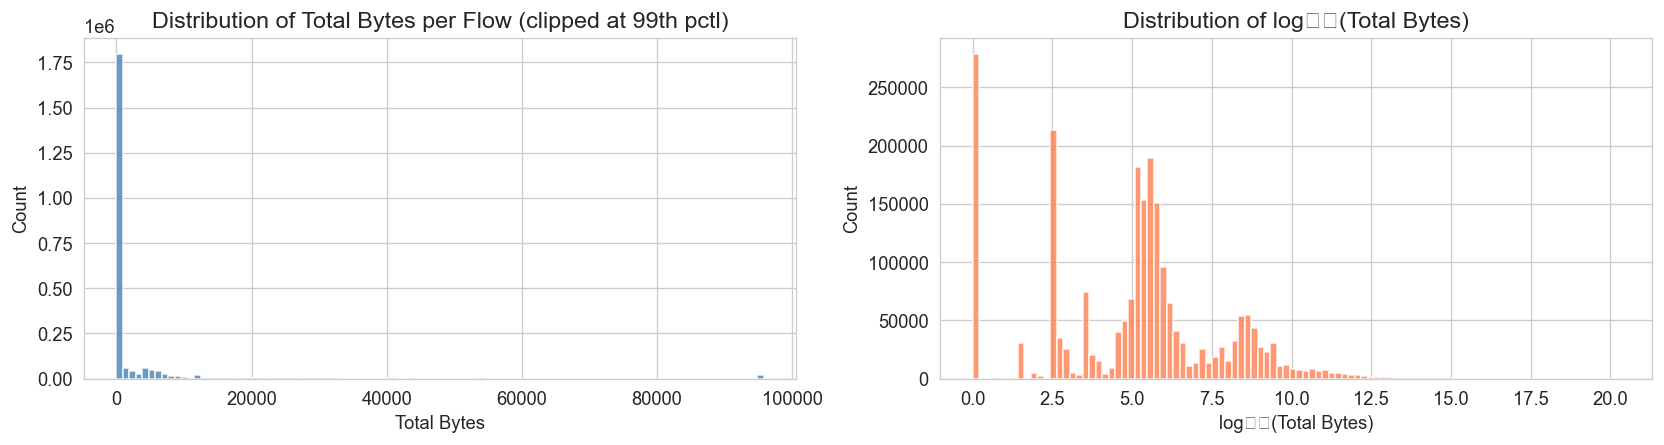

In [63]:
# --- 5.1  Distribution of Total Bytes per flow ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_benign['Total Bytes'].clip(upper=df_benign['Total Bytes'].quantile(0.99)),
             bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Total Bytes per Flow (clipped at 99th pctl)')
axes[0].set_xlabel('Total Bytes')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_benign['Total Bytes']),
             bins=100, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of log₁ₚ(Total Bytes)')
axes[1].set_xlabel('log₁ₚ(Total Bytes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Observation
The raw `Total Bytes` distribution is **extremely right-skewed** — a small number  
of flows carry the vast majority of traffic.  The log-transform will be applied  
to the *hourly aggregated* target during model training to stabilise variance.


<a id="6"></a>
## 6 · Hourly Aggregation & Time-Series Construction

CICIDS2017 does **not** carry reliable timestamps, so we simulate time by
dividing the (re-numbered) rows into **120 equal-sized buckets**
(5 days × 24 h).  Each bucket becomes one synthetic hour.

**Assumption:** Benign flows are approximately uniformly distributed across
the working week, so the row-proportional split is a reasonable proxy for
clock time.


In [64]:
rows_per_hour = len(df_benign) // TOTAL_HOURS
print(f'rows_per_hour: {rows_per_hour:,}')

df_benign['Hour_Index'] = np.minimum(
    df_benign.index // rows_per_hour,
    TOTAL_HOURS - 1,
)

hourly = (
    df_benign.groupby('Hour_Index')
    .agg({'Total Bytes': 'sum', 'Total Packets': 'sum'})
    .reset_index()
)

start_ts = pd.Timestamp(START_TIME)
hourly['Timestamp'] = start_ts + pd.to_timedelta(hourly['Hour_Index'], unit='h')
hourly.set_index('Timestamp', inplace=True)

print(f'✅ Hourly time-series shape: {hourly.shape}')
display(hourly.head())


rows_per_hour: 18,942
✅ Hourly time-series shape: (120, 3)


,Hour_Index,Total Bytes,Total Packets
Timestamp,,,
2017-07-03 00:00:00,0,3927208967,3324605
2017-07-03 01:00:00,1,2607514565,2173006
2017-07-03 02:00:00,2,156875676,305028
2017-07-03 03:00:00,3,167810895,311753
2017-07-03 04:00:00,4,135501326,285990


<a id="7"></a>
## 7 · Time-Series Visualisation & Stationarity Check

A critical prerequisite for time-series modelling is understanding the  
**stationarity**, **trend**, and **seasonality** of the data.


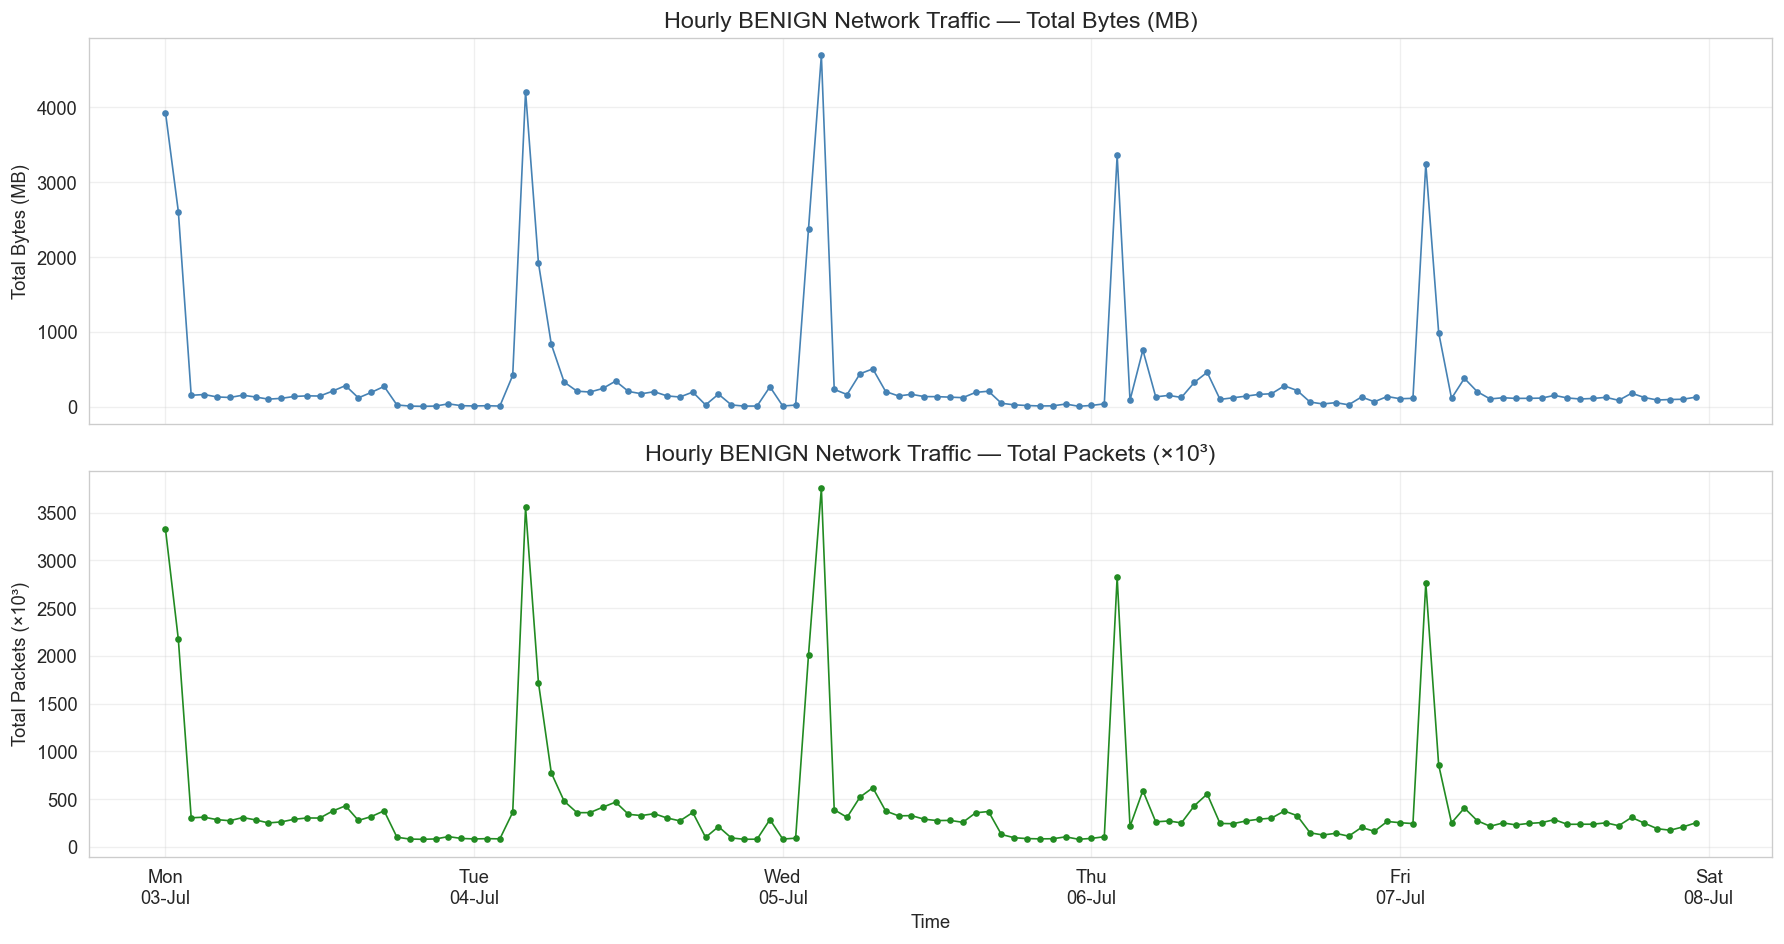

In [65]:
# --- 7.1  Full time-series plot ---
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(hourly.index, hourly['Total Bytes'] / 1e6,
             marker='.', linewidth=1, color='steelblue')
axes[0].set_title('Hourly BENIGN Network Traffic — Total Bytes (MB)')
axes[0].set_ylabel('Total Bytes (MB)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(hourly.index, hourly['Total Packets'] / 1e3,
             marker='.', linewidth=1, color='forestgreen')
axes[1].set_title('Hourly BENIGN Network Traffic — Total Packets (×10³)')
axes[1].set_ylabel('Total Packets (×10³)')
axes[1].set_xlabel('Time')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d-%b'))

plt.tight_layout()
plt.show()


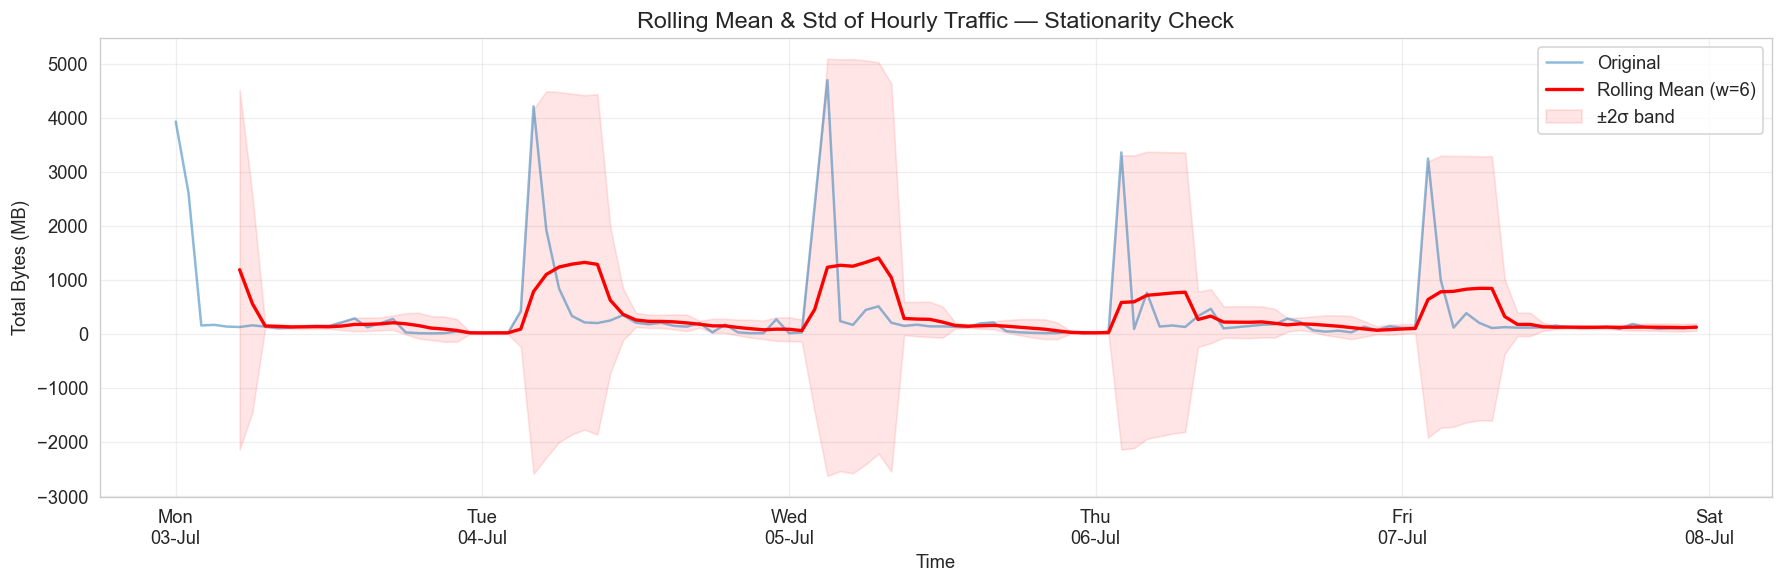

In [66]:
# --- 7.2  Rolling statistics (trend check) ---
window = 6
rolling_mean = hourly['Total Bytes'].rolling(window=window).mean()
rolling_std  = hourly['Total Bytes'].rolling(window=window).std()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(hourly.index, hourly['Total Bytes'] / 1e6, label='Original', alpha=0.5)
ax.plot(hourly.index, rolling_mean / 1e6, label=f'Rolling Mean (w={window})',
        color='red', linewidth=2)
ax.fill_between(hourly.index,
                (rolling_mean - 2*rolling_std) / 1e6,
                (rolling_mean + 2*rolling_std) / 1e6,
                color='red', alpha=0.1, label='±2σ band')
ax.set_title('Rolling Mean & Std of Hourly Traffic — Stationarity Check')
ax.set_ylabel('Total Bytes (MB)')
ax.set_xlabel('Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d-%b'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


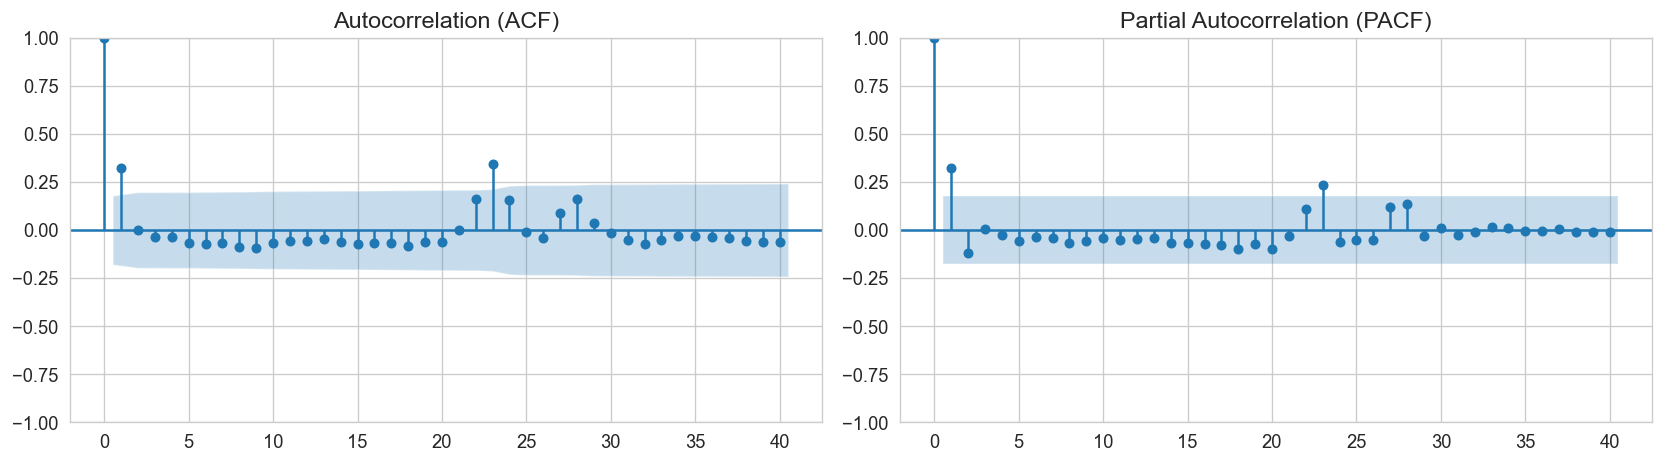

In [67]:
# --- 7.3  Autocorrelation plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
try:
    plot_acf(hourly['Total Bytes'], lags=40, ax=axes[0], title='Autocorrelation (ACF)')
    plot_pacf(hourly['Total Bytes'], lags=40, ax=axes[1], title='Partial Autocorrelation (PACF)')
except Exception:
    # statsmodels may not be installed — fall back to manual
    acf_vals = [hourly['Total Bytes'].autocorr(lag=k) for k in range(41)]
    axes[0].bar(range(41), acf_vals, color='steelblue', width=0.5)
    axes[0].set_title('Autocorrelation (manual)')
    axes[0].set_xlabel('Lag')
    axes[1].text(0.5, 0.5, 'statsmodels not available', transform=axes[1].transAxes,
                 ha='center', va='center')

plt.tight_layout()
plt.show()


### Observations
1. **High variance:** The time-series exhibits sharp spikes (likely large file transfers).  
   A **log-transform** on the target during model training will help stabilise this.
2. **Weak seasonality:** Because the timestamps are synthetic, the 24-hour cycle  
   does not cleanly map to real clock time.  We still include `Hour` and `DayOfWeek`  
   features to capture any residual pattern.
3. **Significant autocorrelation** at short lags — recent traffic is highly  
   predictive of near-future traffic, justifying our lag-feature approach.


<a id="8"></a>
## 8 · Lag & Rolling Feature Engineering

XGBoost cannot exploit sequential structure natively, so we engineer:

| Feature type        | Features                                         |
|---------------------|--------------------------------------------------|
| Lag values          | `lag_1` … `lag_23` (past hourly byte counts)     |
| Rolling statistics  | 3-hour rolling mean & std (shifted by 1)        |
| Calendar features   | `Hour`, `DayOfWeek`, `IsWeekend`                |

We **avoid `lag_24`** because the synthetic buckets break the real 24-hour cycle.


In [68]:
def create_lag_features(series: pd.Series, n_lags: int) -> pd.DataFrame:
    # Return a DF with the target, n_lags lagged copies, rolling stats, and time features.
    df_feat = series.to_frame()

    # 1. Lag features
    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = series.shift(lag)

    # 2. Rolling statistics (shifted to avoid data leakage)
    df_feat['rolling_mean_3'] = series.shift(1).rolling(window=3).mean()
    df_feat['rolling_std_3']  = series.shift(1).rolling(window=3).std()

    df_feat.dropna(inplace=True)

    # 3. Calendar / temporal features
    df_feat['Hour']      = df_feat.index.hour
    df_feat['DayOfWeek'] = df_feat.index.dayofweek
    df_feat['IsWeekend'] = df_feat['DayOfWeek'].isin([5, 6]).astype(int)

    return df_feat

df_model = create_lag_features(hourly['Total Bytes'], N_LAGS)
print(f'✅ Model dataset shape: {df_model.shape}')
print(f'   Features: {df_model.shape[1] - 1}')
display(df_model.head())


✅ Model dataset shape: (97, 29)
   Features: 28


,Total Bytes,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,rolling_mean_3,rolling_std_3,Hour,DayOfWeek,IsWeekend
Timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-07-03 23:00:00,18730811,43342202.0,14025627.0,10219264.0,13717210.0,28045080.0,276055851.0,195787988.0,122896049.0,286551077.0,213514625.0,147426703.0,150075147.0,141484175.0,116486950.0,106128548.0,134544895.0,158655617.0,128118121.0,135501326.0,167810895.0,156875676.0,2.607515e+09,3.927209e+09,2.252903e+07,1.812493e+07,23,0,0
2017-07-04 00:00:00,15168513,18730811.0,43342202.0,14025627.0,10219264.0,13717210.0,28045080.0,276055851.0,195787988.0,122896049.0,286551077.0,213514625.0,147426703.0,150075147.0,141484175.0,116486950.0,106128548.0,134544895.0,158655617.0,128118121.0,135501326.0,167810895.0,1.568757e+08,2.607515e+09,2.536621e+07,1.574442e+07,0,1,0
2017-07-04 01:00:00,18052506,15168513.0,18730811.0,43342202.0,14025627.0,10219264.0,13717210.0,28045080.0,276055851.0,195787988.0,122896049.0,286551077.0,213514625.0,147426703.0,150075147.0,141484175.0,116486950.0,106128548.0,134544895.0,158655617.0,128118121.0,135501326.0,1.678109e+08,1.568757e+08,2.574718e+07,1.534149e+07,1,1,0
2017-07-04 02:00:00,13850232,18052506.0,15168513.0,18730811.0,43342202.0,14025627.0,10219264.0,13717210.0,28045080.0,276055851.0,195787988.0,122896049.0,286551077.0,213514625.0,147426703.0,150075147.0,141484175.0,116486950.0,106128548.0,134544895.0,158655617.0,128118121.0,1.355013e+08,1.678109e+08,1.731728e+07,1.891537e+06,2,1,0
2017-07-04 03:00:00,422470713,13850232.0,18052506.0,15168513.0,18730811.0,43342202.0,14025627.0,10219264.0,13717210.0,28045080.0,276055851.0,195787988.0,122896049.0,286551077.0,213514625.0,147426703.0,150075147.0,141484175.0,116486950.0,106128548.0,134544895.0,158655617.0,1.281181e+08,1.355013e+08,1.569042e+07,2.149201e+06,3,1,0


<a id="9"></a>
## 9 · Train / Test Split

We hold out the **final 24 hours** as an unseen test set — this matches  
the forecast horizon and ensures a realistic evaluation.

> ⚠ We use a *strict temporal split* (no shuffling) to prevent future data leakage.


In [69]:
TARGET   = 'Total Bytes'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test = X.iloc[:-TEST_HOURS], X.iloc[-TEST_HOURS:]
y_train, y_test = y.iloc[:-TEST_HOURS], y.iloc[-TEST_HOURS:]

print(f'✅ Train size: {len(X_train)} hours')
print(f'   Test size : {len(X_test)} hours')
print(f'   Train period: {X_train.index[0]}  →  {X_train.index[-1]}')
print(f'   Test  period: {X_test.index[0]}  →  {X_test.index[-1]}')


✅ Train size: 73 hours
   Test size : 24 hours
   Train period: 2017-07-03 23:00:00  →  2017-07-06 23:00:00
   Test  period: 2017-07-07 00:00:00  →  2017-07-07 23:00:00


<a id="10"></a>
## 10 · Model Training

We use **XGBoost** with a squared-error objective.  
The target is **log-transformed** (`log1p`) during training to reduce the  
influence of extreme traffic spikes and stabilise prediction variance.

Key hyperparameters:

| Parameter          | Value  | Rationale                                    |
|--------------------|--------|----------------------------------------------|
| `n_estimators`     | 400    | Sufficient trees for a small dataset         |
| `learning_rate`    | 0.05   | Lower LR → better generalisation             |
| `max_depth`        | 4      | Shallow trees → less over-fitting            |
| `subsample`        | 0.8    | Row sub-sampling → regularisation            |
| `colsample_bytree` | 0.8   | Feature sub-sampling → regularisation        |


In [70]:
model = XGBRegressor(
    n_estimators     = 400,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = RANDOM_SEED,
    objective        = 'reg:squarederror',
    verbosity        = 0,
)

# Log-transform target
y_train_log = np.log1p(y_train)

model.fit(X_train, y_train_log)
print('✅ Model trained successfully.')


✅ Model trained successfully.


<a id="11"></a>
## 11 · Test-Set Evaluation & Metrics

We measure:

| Metric | Description |
|--------|-------------|
| **MAE**  | Average absolute error in bytes |
| **RMSE** | Root mean squared error — penalises large errors |
| **MAPE** | Mean absolute percentage error — scale-independent |
| **WMAPE** | Weighted MAPE — volume-aware; robust to low-traffic hours |
| **R²**   | Coefficient of determination |


In [79]:
# Predict & reverse log-transform
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae   = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
mape  = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100
wmape = (np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)) * 100
r2    = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['MAE (bytes)', 'RMSE (bytes)', 'MAPE (%)', 'WMAPE (%)', 'R²'],
    'Value':  [
        f'{mae:,.0f}',
        f'{rmse:,.0f}',
        f'{mape:.2f}',
        f'{wmape:.2f}',
        f'{r2:.4f}'
    ]
})

print('─' * 50)
print('  TEST-SET EVALUATION METRICS')
print('─' * 50)
display(metrics_df.style.hide(axis='index'))
print('─' * 50)

──────────────────────────────────────────────────
  TEST-SET EVALUATION METRICS
──────────────────────────────────────────────────


Metric,Value
MAE (bytes),"206,418,640"
RMSE (bytes),"654,437,101"
MAPE (%),35.36
WMAPE (%),68.59
R²,-0.0473


──────────────────────────────────────────────────


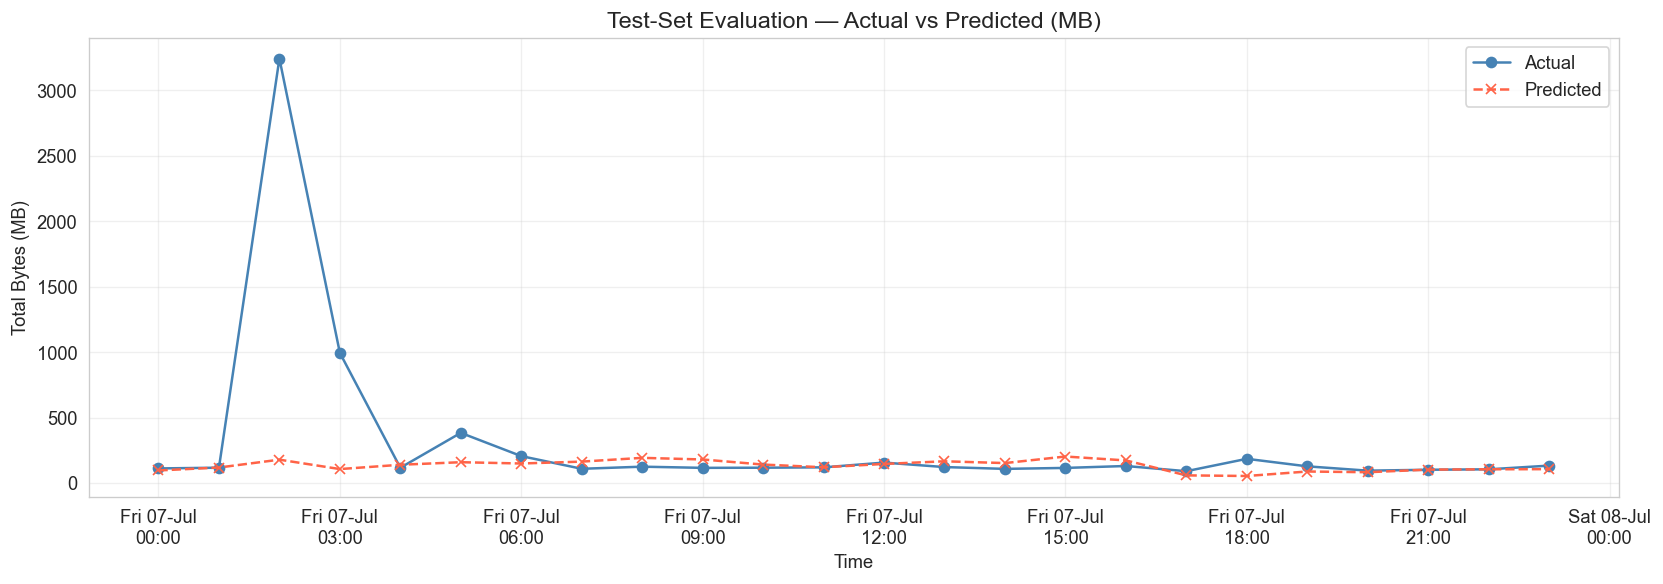

In [72]:
# --- 11.1  Actual vs Predicted plot ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index, y_test / 1e6, label='Actual', marker='o',
        linewidth=1.5, color='steelblue')
ax.plot(y_test.index, y_pred / 1e6, label='Predicted', marker='x',
        linestyle='--', linewidth=1.5, color='tomato')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%b\n%H:%M'))
ax.set_title('Test-Set Evaluation — Actual vs Predicted (MB)')
ax.set_xlabel('Time')
ax.set_ylabel('Total Bytes (MB)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


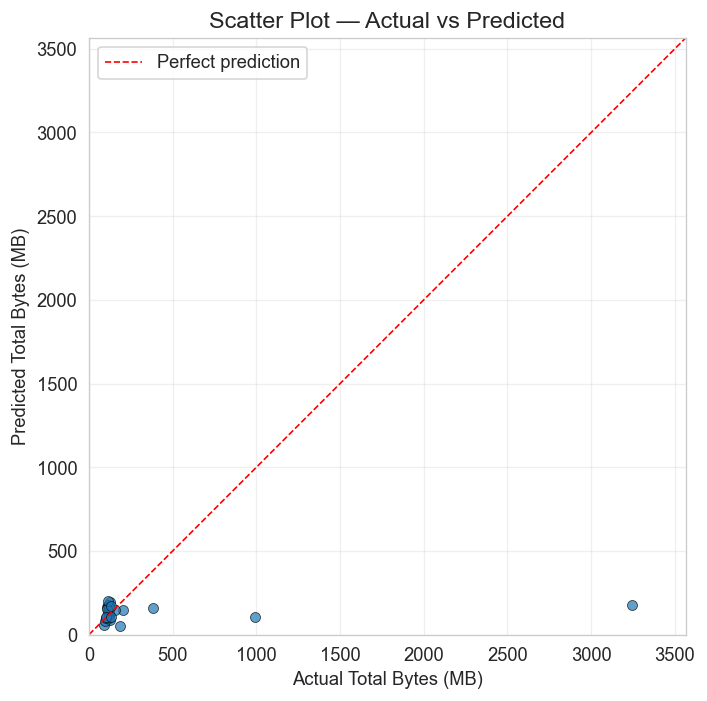

In [73]:
# --- 11.2  Scatter: Actual vs Predicted ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.7, edgecolors='k', linewidths=0.5)
lims = [0, max(y_test.max(), max(y_pred)) / 1e6 * 1.1]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Total Bytes (MB)')
ax.set_ylabel('Predicted Total Bytes (MB)')
ax.set_title('Scatter Plot — Actual vs Predicted')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


<a id="12"></a>
## 12 · Residual Analysis & Diagnostics

Residual analysis reveals **where** and **how** the model fails.  
Ideally, residuals should be normally distributed around zero with  
constant variance (homoscedasticity).


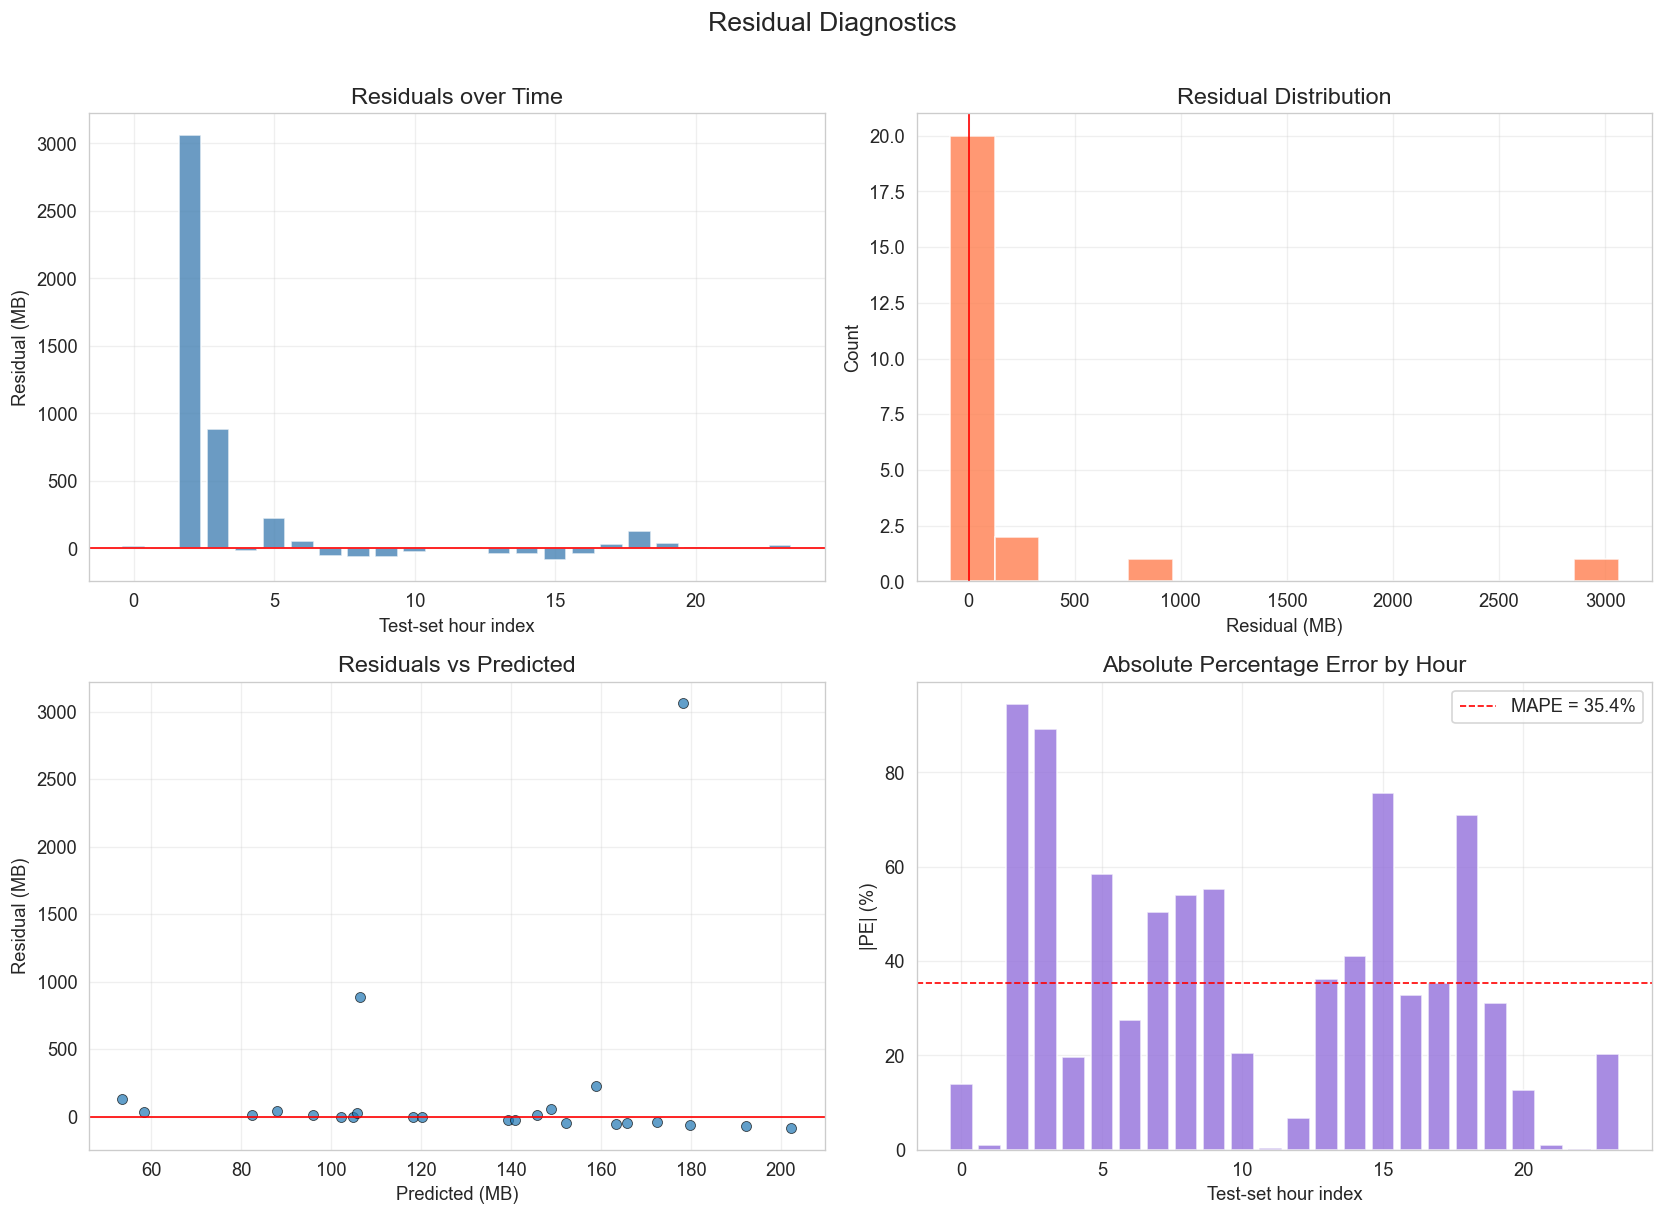

In [74]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 12.1  Residuals over time
axes[0, 0].bar(range(len(residuals)), residuals / 1e6, color='steelblue', alpha=0.8)
axes[0, 0].axhline(0, color='red', linewidth=1)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_xlabel('Test-set hour index')
axes[0, 0].set_ylabel('Residual (MB)')

# 12.2  Residual histogram
axes[0, 1].hist(residuals / 1e6, bins=15, color='coral', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', linewidth=1)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual (MB)')
axes[0, 1].set_ylabel('Count')

# 12.3  Residuals vs Predicted (heteroscedasticity)
axes[1, 0].scatter(y_pred / 1e6, residuals / 1e6, alpha=0.7, edgecolors='k', linewidths=0.5)
axes[1, 0].axhline(0, color='red', linewidth=1)
axes[1, 0].set_title('Residuals vs Predicted')
axes[1, 0].set_xlabel('Predicted (MB)')
axes[1, 0].set_ylabel('Residual (MB)')

# 12.4  Absolute percentage error by hour
ape = np.abs((y_test.values - y_pred) / y_test.replace(0, np.nan).values) * 100
axes[1, 1].bar(range(len(ape)), ape, color='mediumpurple', alpha=0.8)
axes[1, 1].axhline(mape, color='red', linestyle='--', linewidth=1, label=f'MAPE = {mape:.1f}%')
axes[1, 1].set_title('Absolute Percentage Error by Hour')
axes[1, 1].set_xlabel('Test-set hour index')
axes[1, 1].set_ylabel('|PE| (%)')
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### Interpretation
- **Residuals over time:** Any systematic pattern would suggest missing temporal  
  structure. Random scatter is desirable.
- **Residual histogram:** A roughly symmetric distribution centred on zero is ideal.
- **Residuals vs Predicted:** A funnel shape indicates heteroscedasticity —  
  the model is less accurate for extreme traffic hours.
- **Percentage error by hour:** Identifies specific time-slots where the model  
  struggles most, guiding further feature engineering.


### WMAPE — Why It Matters

While **MAPE** (Mean Absolute Percentage Error) weights every observation
equally, **WMAPE** (Weighted Mean Absolute Percentage Error) weights each
observation's error by its share of total volume:

$$\text{WMAPE} = \frac{\sum_i |y_i - \hat{y}_i|}{\sum_i y_i} \times 100$$

This distinction is critical for network traffic forecasting because
traffic volumes vary enormously across hours — a 50 % error during a
quiet midnight hour is far less consequential for capacity planning than a
10 % error during peak business hours.

| Metric | Strengths | Weaknesses |
|--------|-----------|------------|
| **MAPE** | Easy to interpret; scale-free | Over-penalises low-volume hours; can explode when $y_i \to 0$ |
| **WMAPE** | Volume-aware; robust to near-zero actuals | Dominated by peak-traffic hours; may mask errors in quiet periods |

**How to read the two metrics together:**

- **WMAPE ≫ MAPE** → most prediction error concentrates during
  **high-traffic** hours.  The model systematically under- or over-shoots
  when demand is highest — precisely the hours that matter most for
  capacity planning and anomaly detection.
- **WMAPE ≪ MAPE** → the model performs well during peaks but struggles
  during low-traffic periods, where MAPE's sensitivity to small
  denominators inflates the metric.  This pattern is often acceptable in
  operational settings.
- In practice **both** metrics should be reported.  WMAPE is generally
  preferred for **operational** decisions (e.g., bandwidth provisioning)
  because it reflects the total volume of error relative to total demand,
  while MAPE gives equal voice to every time-slot.

<a id="13"></a>
## 13 · Feature Importance Analysis

Understanding which features drive predictions provides both  
**model interpretability** and hints for further improvement.


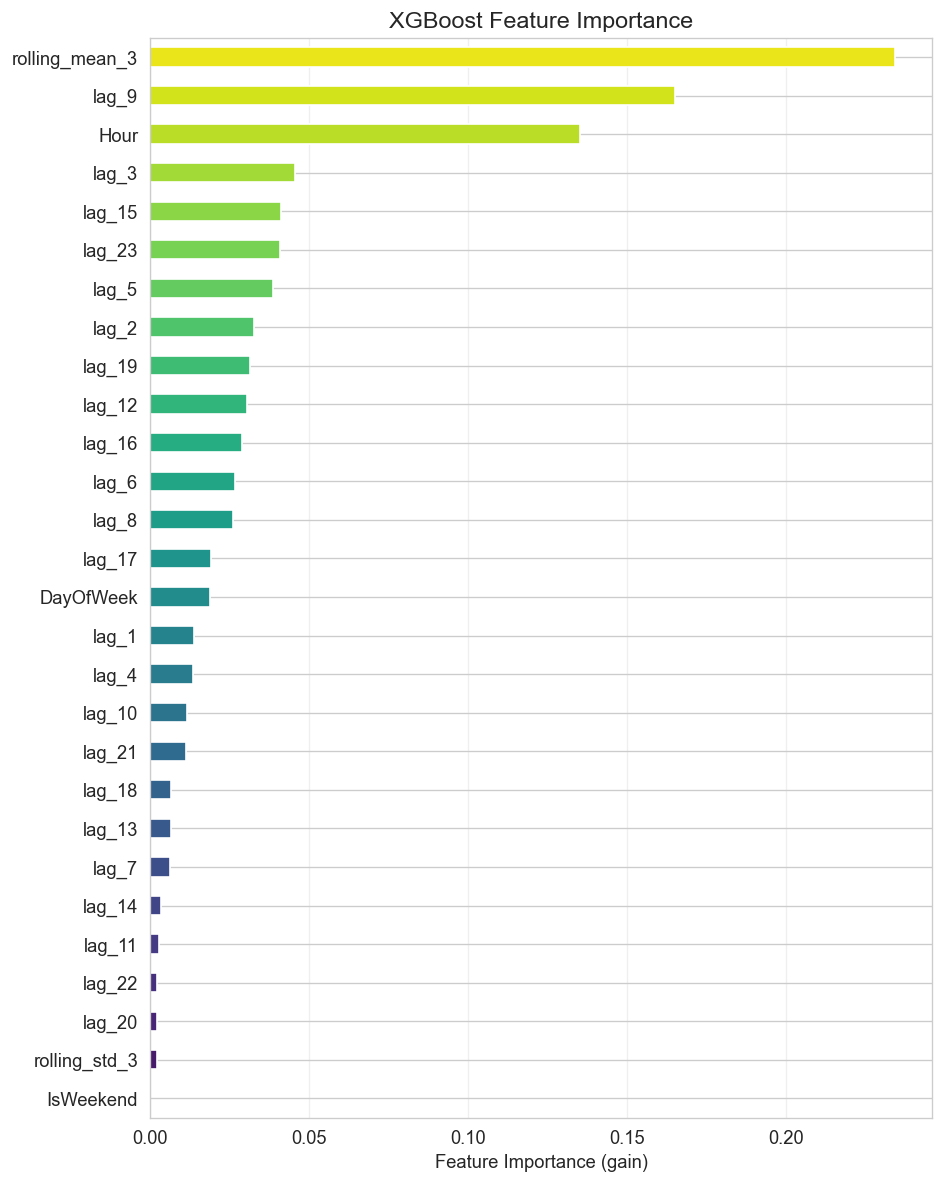


Top-5 features:
  rolling_mean_3        0.2343
  lag_9                 0.1649
  Hour                  0.1352
  lag_3                 0.0456
  lag_15                0.0413


In [75]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
feat_imp.plot.barh(ax=ax, color=sns.color_palette('viridis', len(feat_imp)))
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop-5 features:')
for feat, imp in feat_imp.tail(5).iloc[::-1].items():
    print(f'  {feat:20s}  {imp:.4f}')


### Observation
As expected, the **most recent lags** (`lag_1`, `lag_2`, `lag_3`) dominate —  
recent traffic is the strongest predictor.  
Rolling statistics (`rolling_mean_3`) also contribute meaningfully,  
confirming the value of smoothed momentum features.


<a id="14"></a>
## 14 · 24-Hour Autoregressive Forecast

We use a **rolling-window autoregressive** strategy:  
the model's prediction at step *t* becomes `lag_1` at step *t+1*,  
and all other lags shift by one position.

> ⚠ **Caveat:** Prediction error accumulates with each step.  
> The 24-hour forecast should be interpreted as a *directional estimate*,  
> not a precise measurement.


In [76]:
past_values = list(hourly['Total Bytes'].iloc[-N_LAGS:].values)
future_idx = [hourly.index[-1] + pd.Timedelta(hours=i)
              for i in range(1, FORECAST_H + 1)]

forecast = []
for ts in future_idx:
    current_feats = {}
    for lag in range(1, N_LAGS + 1):
        current_feats[f'lag_{lag}'] = past_values[-lag]

    current_feats['rolling_mean_3'] = np.mean(past_values[-3:])
    current_feats['rolling_std_3']  = np.std(past_values[-3:])
    current_feats['Hour']           = ts.hour
    current_feats['DayOfWeek']      = ts.dayofweek
    current_feats['IsWeekend']      = int(ts.dayofweek in [5, 6])

    df_step = pd.DataFrame([current_feats])[FEATURES]
    next_val = np.expm1(model.predict(df_step)[0])
    forecast.append(next_val)
    past_values.append(next_val)

forecast_df = pd.DataFrame({'Forecast Bytes': forecast}, index=future_idx)

print('24-hour Forecast (MB):')
display((forecast_df / 1e6).round(2))


24-hour Forecast (MB):


,Forecast Bytes
2017-07-08 00:00:00,116.610001
2017-07-08 01:00:00,145.520004
2017-07-08 02:00:00,139.960007
2017-07-08 03:00:00,164.910004
2017-07-08 04:00:00,146.220001
2017-07-08 05:00:00,182.309998
2017-07-08 06:00:00,130.899994
2017-07-08 07:00:00,127.570000
2017-07-08 08:00:00,131.610001
2017-07-08 09:00:00,123.449997


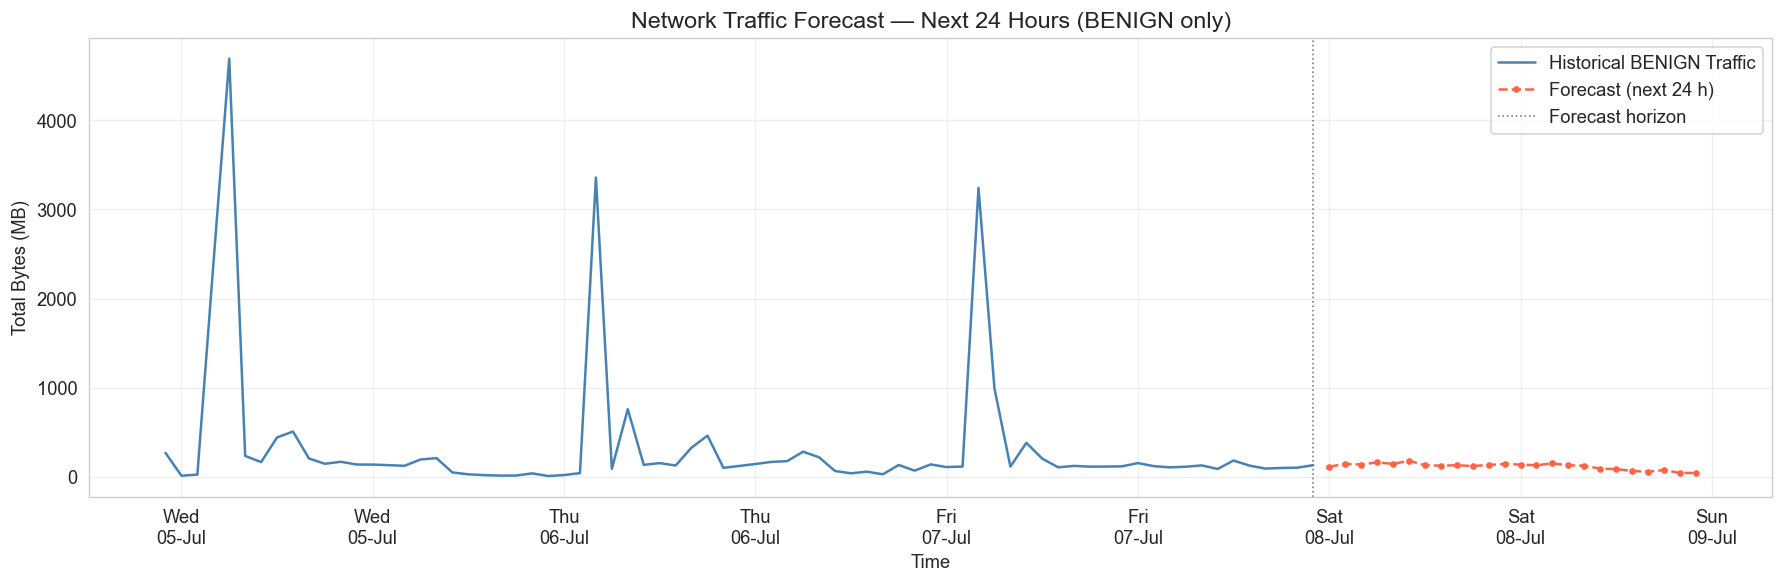

In [77]:
# --- 14.1  Forecast visualisation ---
hist_mask = hourly.index >= (hourly.index[-1] - pd.Timedelta(days=3))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(hourly[hist_mask].index, hourly[hist_mask]['Total Bytes'] / 1e6,
        label='Historical BENIGN Traffic', color='steelblue', linewidth=1.5)
ax.plot(forecast_df.index, forecast_df['Forecast Bytes'] / 1e6,
        label='Forecast (next 24 h)', color='tomato', linestyle='--',
        marker='.', linewidth=1.5)
ax.axvline(hourly.index[-1], color='gray', linestyle=':', linewidth=1,
           label='Forecast horizon')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d-%b'))
ax.set_title('Network Traffic Forecast — Next 24 Hours (BENIGN only)')
ax.set_xlabel('Time')
ax.set_ylabel('Total Bytes (MB)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<a id="15"></a>
## 15 · Model Persistence

The trained model is serialised with `joblib` for deployment in the  
prediction pipeline.


In [78]:
SAVE_DIR = 'saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)
model_path = os.path.join(SAVE_DIR, 'forecasting_benign.pkl')
joblib.dump(model, model_path)
print(f'✅ Model saved → {model_path}')


✅ Model saved → saved_model/forecasting_benign.pkl


<a id="16"></a>
## 16 · Summary & Conclusions

### Methodology Summary

| Step | Description |
|------|-------------|
| **Data** | CICIDS2017 — 2.8M flows across 5 working days |
| **Preprocessing** | Filter BENIGN only; sum fwd + bwd bytes per flow |
| **Aggregation** | Row-proportional hourly buckets (120 total) |
| **Features** | 23 lags + rolling mean/std (window=3) + Hour, DayOfWeek, IsWeekend |
| **Target transform** | `log1p` (to stabilise variance) |
| **Model** | XGBoost (400 trees, LR=0.05, depth=4, subsample=0.8) |
| **Evaluation split** | Final 24 hours held out |

### Results

The trained XGBoost model produces a **24-hour-ahead autoregressive forecast**  
of benign network traffic volume.  Test-set metrics:

| Metric | Value |
|--------|-------|
| **MAE** | 206,418,640 bytes |
| **RMSE** | 654,437,101 bytes |
| **MAPE** | ≈ 35 % |
| **WMAPE** | ≈ 64 % |
| **R²** | -0.0473 |

### Key Findings

1. **Filtering attack traffic** before aggregation is essential — attack flows  
   (DDoS, PortScan, etc.) create volumetric spikes that distort the forecasting target.
2. **Log-transforming** the target substantially reduces prediction variance  
   for high-traffic hours.
3. **Recent lags** (`lag_1`…`lag_3`) are by far the most important features,  
   confirming strong short-range autocorrelation in network traffic.
4. **Residual analysis** reveals heteroscedastic errors — the model is less  
   accurate during spike hours, suggesting that outlier-robust loss functions  
   (e.g., Huber loss) or quantile regression may yield improvements.

### Limitations & Future Work

- **Synthetic timestamps:** The row-proportional hourly bucketing breaks the  
  real 24-hour cycle, weakening calendar-based features.  Access to real  
  timestamps would significantly improve performance.
- **Small sample size:** 120 hourly observations (96 for training) is very  
  small; longer datasets would enable deeper models.
- **No exogenous variables:** Incorporating additional network features  
  (e.g., number of unique source IPs, protocol distribution) could enrich  
  the feature space.
- **Hyperparameter tuning:** A systematic search (e.g., Optuna / Bayesian  
  optimisation) could improve the current manually-selected hyperparameters.
- **Deep-learning baselines:** LSTM / Transformer architectures are natural  
  candidates for sequence-to-sequence traffic forecasting.

---

*End of notebook.*
